In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.preprocessing import StandardScaler , RobustScaler
from scipy import stats
import matplotlib.ticker as ticker
import datetime as dt
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_transformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor

!pip install catboost
from catboost import CatBoostRegressor
import time
from sklearn import metrics


!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/datasets/AB_NYC_2019.csv')

# Basic information about the dataset
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()




Dataset shape: (14884, 16)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14884 entries, 0 to 14883
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14884 non-null  int64  
 1   name                            14872 non-null  object 
 2   host_id                         14884 non-null  int64  
 3   host_name                       14871 non-null  object 
 4   neighbourhood_group             14883 non-null  object 
 5   neighbourhood                   14883 non-null  object 
 6   latitude                        14883 non-null  float64
 7   longitude                       14883 non-null  float64
 8   room_type                       14883 non-null  object 
 9   price                           14883 non-null  float64
 10  minimum_nights                  14883 non-null  float64
 11  number_of_reviews               14883 non-null  flo

Here are the definitions of each column in your dataset:

1. **id**: A unique identifier for each listing.
2. **name**: The title or name of the listing.
3. **host_id**: A unique identifier for the host who listed the property.
4. **host_name**: The name of the host.
5. **neighbourhood_group**: A broader classification of the neighbourhood (e.g., district or city area).
6. **neighbourhood**: The specific neighbourhood where the listing is located.
7. **latitude**: The geographical latitude coordinate of the listing location.
8. **longitude**: The geographical longitude coordinate of the listing location.
9. **room_type**: The type of accommodation offered (e.g., Entire home/apt, Private room, Shared room).
10. **price**: The cost per night for the listing in the local currency.
11. **minimum_nights**: The minimum number of nights required for a booking.
12. **number_of_reviews**: The total number of reviews the listing has received.
13. **last_review**: The date of the most recent review for the listing.
14. **reviews_per_month**: The average number of reviews the listing receives per month.
15. **calculated_host_listings_count**: The total number of listings managed by the host.
16. **availability_365**: The number of days the listing is available for booking in a year (out of 365 days).


In [ ]:
# Display the first few rows
print("\nFirst 5 rows:")
df.head()




First 5 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9.0,2018-10-19,0.21,6.0,365.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45.0,2019-05-21,0.38,2.0,355.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0.0,NaN,NaN,1.0,365.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270.0,2019-07-05,4.64,1.0,194.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9.0,2018-11-19,0.10,1.0,0.0


In [ ]:
# Drop columns that are less useful
df = df.drop(['id', 'name', 'host_id', 'host_name','last_review','neighbourhood'], axis=1)

In [ ]:
# This feature represents the total cost of the house for the minimum number of nights. It takes the total of the price for minimum nights.
df['NEW_total_cost'] = df['price'] * df['minimum_nights']

# This feature can be used to estimate for how long a house has been listed. This duration is calculated by dividing the total number of reviews that the house has received by the number of reviews per month.
df['NEW_estimated_listed_months'] = df['number_of_reviews'] / df['reviews_per_month']

# This feature gives the ratio of how long a house is available throughout the year.
df['NEW_availability_ratio'] = df['availability_365'] / 365

# This feature gives the daily average reviews a host receives. It divides the reviews per month by the number of days in a month.
df['NEW_daily_average_reviews'] = df['reviews_per_month'] / 30

# This feature estimates how much a host can earn in a year. It multiplies the price of a house with how many days it is available in a year.
df['NEW_annual_income'] = df['price'] * df['availability_365']

# This feature estimates the average duration a customer stays. It divides the total number of reviews by the reviews per month.
df['NEW_average_stay_duration'] = df['number_of_reviews'] / df['reviews_per_month']

# This feature gives the occupancy rate of a house throughout the year. It subtracts from 365 the number of days a house is available in a year.
df['NEW_house_occupancy_rate'] = 365 - df['availability_365']

# This feature determines the minimum amount a house can get for a booking. It multiplies the price of a house with the minimum nights.
df['NEW_minimum_income'] = df['price'] * df['minimum_nights']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14884 entries, 0 to 14883
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             14883 non-null  object 
 1   latitude                        14883 non-null  float64
 2   longitude                       14883 non-null  float64
 3   room_type                       14883 non-null  object 
 4   price                           14883 non-null  float64
 5   minimum_nights                  14883 non-null  float64
 6   number_of_reviews               14883 non-null  float64
 7   reviews_per_month               12428 non-null  float64
 8   calculated_host_listings_count  14883 non-null  float64
 9   availability_365                14883 non-null  float64
 10  NEW_total_cost                  14883 non-null  float64
 11  NEW_estimated_listed_months     12428 non-null  float64
 12  NEW_availability_ratio          

In [ ]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())




Missing values per column:
neighbourhood_group                  1
latitude                             1
longitude                            1
room_type                            1
price                                1
minimum_nights                       1
number_of_reviews                    1
reviews_per_month                 2456
calculated_host_listings_count       1
availability_365                     1
NEW_total_cost                       1
NEW_estimated_listed_months       2456
NEW_availability_ratio               1
NEW_daily_average_reviews         2456
NEW_annual_income                    1
NEW_average_stay_duration         2456
NEW_house_occupancy_rate             1
NEW_minimum_income                   1
dtype: int64


In [ ]:
# Identify columns with exactly one missing value
missing_cols = ['neighbourhood_group', 'latitude', 'longitude',
                'room_type', 'price', 'minimum_nights', 'number_of_reviews',
                'calculated_host_listings_count', 'availability_365','NEW_minimum_income',
                'NEW_house_occupancy_rate','NEW_annual_income','NEW_availability_ratio','NEW_total_cost']
# Check how many rows we removed
print(f"Original shape: {df.shape}")

# Drop rows with missing values in these columns
df = df.dropna(subset=missing_cols)


print(f"Shape after dropping missing values: {df.shape}")

Original shape: (14884, 18)
Shape after dropping missing values: (14883, 18)


In [ ]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())




Missing values per column:
neighbourhood_group                  0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 2455
calculated_host_listings_count       0
availability_365                     0
NEW_total_cost                       0
NEW_estimated_listed_months       2455
NEW_availability_ratio               0
NEW_daily_average_reviews         2455
NEW_annual_income                    0
NEW_average_stay_duration         2455
NEW_house_occupancy_rate             0
NEW_minimum_income                   0
dtype: int64


In [ ]:
# Check for duplicate records
print("\nNumber of duplicate rows:", df.duplicated().sum())




Number of duplicate rows: 0


In [ ]:
# Check statistical summary
print("\nStatistical summary of numerical columns:")
display(df.describe())




Statistical summary of numerical columns:


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,NEW_total_cost,NEW_estimated_listed_months,NEW_availability_ratio,NEW_daily_average_reviews,NEW_annual_income,NEW_average_stay_duration,NEW_house_occupancy_rate,NEW_minimum_income
count,14883.000000,14883.000000,14883.000000,14883.000000,14883.000000,12428.000000,14883.000000,14883.000000,14883.000000,12428.000000,14883.000000,12428.000000,1.488300e+04,12428.000000,14883.000000,14883.000000
mean,40.729763,-73.958634,155.733118,7.485252,39.405832,0.877399,3.124504,107.324531,1333.834711,52.800233,0.294040,0.029247,1.771101e+04,52.800233,257.675469,1333.834711
std,0.052082,0.036243,247.072148,25.980234,64.194251,1.209976,10.488179,134.440878,13372.034186,18.831111,0.368331,0.040333,5.451634e+04,18.831111,134.440878,13372.034186
min,40.499790,-74.240840,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000,18.000000,1.000000,0.000000,0.000333,0.000000e+00,1.000000,0.000000,18.000000
25%,40.689645,-73.983615,75.000000,1.000000,1.000000,0.090000,1.000000,0.000000,150.000000,42.727273,0.000000,0.003000,0.000000e+00,42.727273,127.000000,150.000000
50%,40.723370,-73.958900,117.000000,3.000000,10.000000,0.330000,1.000000,11.000000,345.000000,50.000000,0.030137,0.011000,1.170000e+03,50.000000,354.000000,345.000000
75%,40.763960,-73.942780,176.000000,5.000000,49.000000,1.202500,2.000000,238.000000,750.000000,61.189227,0.652055,0.040083,2.332500e+04,61.189227,365.000000,750.000000
max,40.908040,-73.712990,10000.000000,1250.000000,629.000000,14.580000,121.000000,365.000000,1000000.000000,128.571429,1.000000,0.486000,2.920000e+06,128.571429,365.000000,1000000.000000


In [ ]:
# Check unique values for categorical columns
print("\nUnique values in categorical columns:")
for col in ['neighbourhood_group', 'room_type']:
    print(f"{col}: {df[col].nunique()} unique values")




Unique values in categorical columns:
neighbourhood_group: 5 unique values
room_type: 3 unique values


In [ ]:
# Set the visual style
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
colors = sns.color_palette('viridis', 5)


In [ ]:
# Define df_viz
df_viz = df  # Using your entire DataFrame

# 1. GEOGRAPHICAL DISTRIBUTION ANALYSIS
# Create a map of NYC Airbnb listings
def create_nyc_map(data):
    # Create base map centered on NYC
    nyc_map = folium.Map(location=[40.730610, -73.935242], zoom_start=11, tiles='CartoDB positron')

    # Create a marker cluster
    marker_cluster = MarkerCluster().add_to(nyc_map)

    # Sample for better performance (if needed)
    if len(data) > 3000:
        data_sample = data.sample(3000, random_state=42)
    else:
        data_sample = data

    # Add price and room type markers
    for idx, row in data_sample.iterrows():
        # Set color based on room type
        if row['room_type'] == 'Entire home/apt':
            color = 'red'
        elif row['room_type'] == 'Private room':
            color = 'blue'
        else:
            color = 'green'

        # Create popup text with only available columns
        popup_text = f"""
        Price: ${row['price']}<br>
        Room Type: {row['room_type']}<br>
        Reviews: {row['number_of_reviews']}
        """

        # Add marker to cluster
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(popup_text, max_width=300),
            icon=folium.Icon(color=color, icon='home')
        ).add_to(marker_cluster)

    # Add a heatmap layer
    heat_data = [[row['latitude'], row['longitude'], row['price']] for idx, row in data_sample.iterrows()]
    HeatMap(heat_data, radius=15).add_to(nyc_map)

    return nyc_map

# Save the map for later display
nyc_map = create_nyc_map(df_viz)
nyc_map.save('nyc_airbnb_map.html')

nyc_map

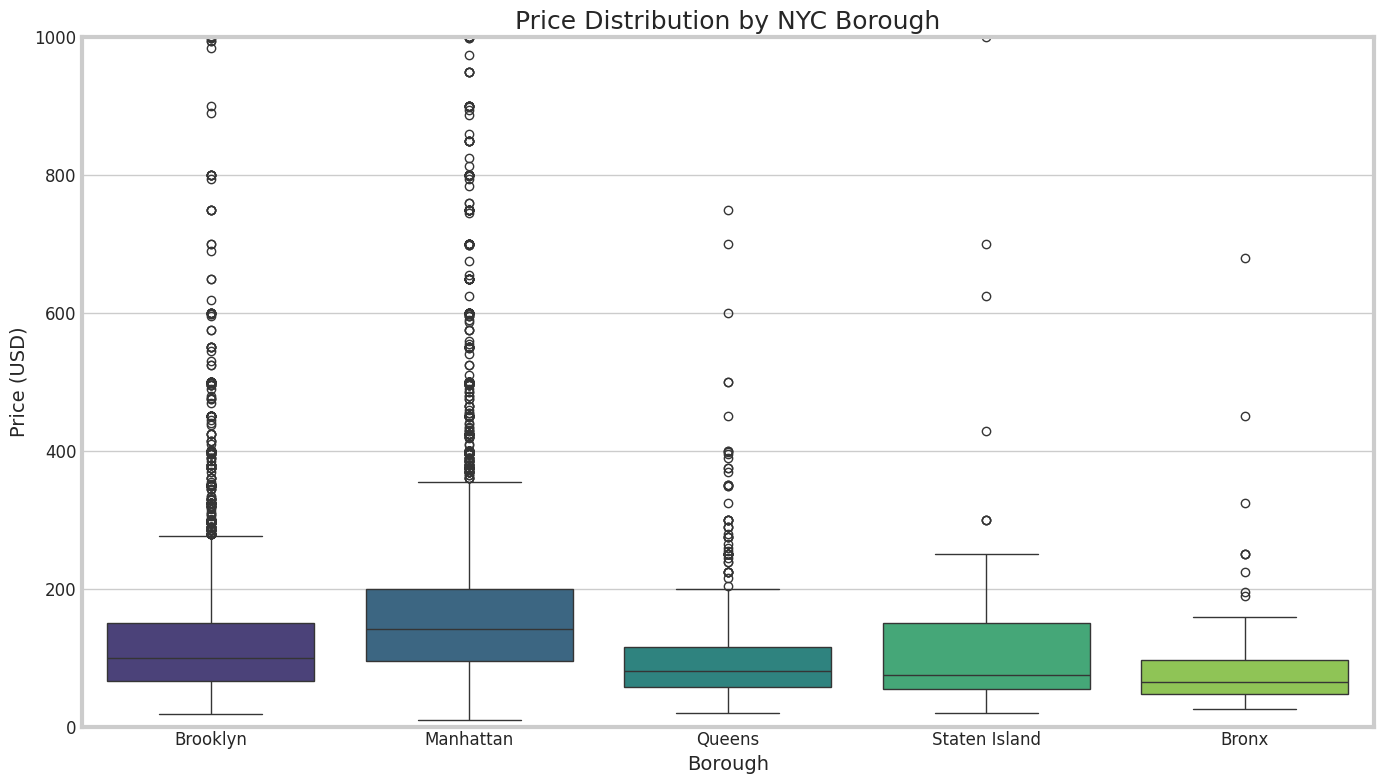

In [ ]:

# 2. PRICE ANALYSIS
# Distribution of prices by borough
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='neighbourhood_group', y='price', data=df_viz, palette='viridis')
ax.set_title('Price Distribution by NYC Borough', fontsize=18)
ax.set_xlabel('Borough', fontsize=14)
ax.set_ylabel('Price (USD)', fontsize=14)
plt.xticks(rotation=0)
plt.ylim(0,1000)
plt.tight_layout()
plt.savefig('price_by_borough.png', dpi=300, bbox_inches='tight')



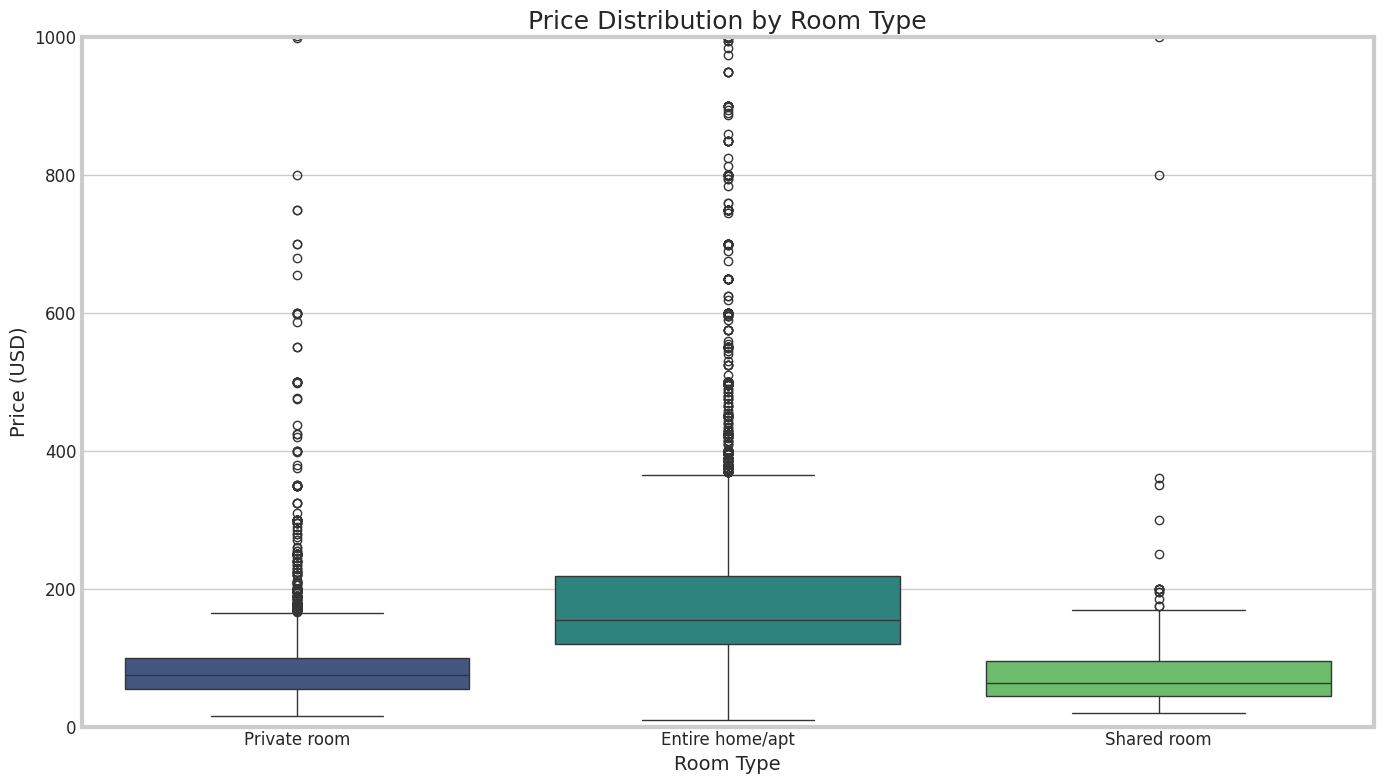

In [ ]:
# Room type price comparison
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='room_type', y='price', data=df_viz, palette='viridis')
ax.set_title('Price Distribution by Room Type', fontsize=18)
ax.set_xlabel('Room Type', fontsize=14)
ax.set_ylabel('Price (USD)', fontsize=14)
plt.ylim(0,1000)
plt.tight_layout()
plt.savefig('price_by_room_type.png', dpi=300, bbox_inches='tight')



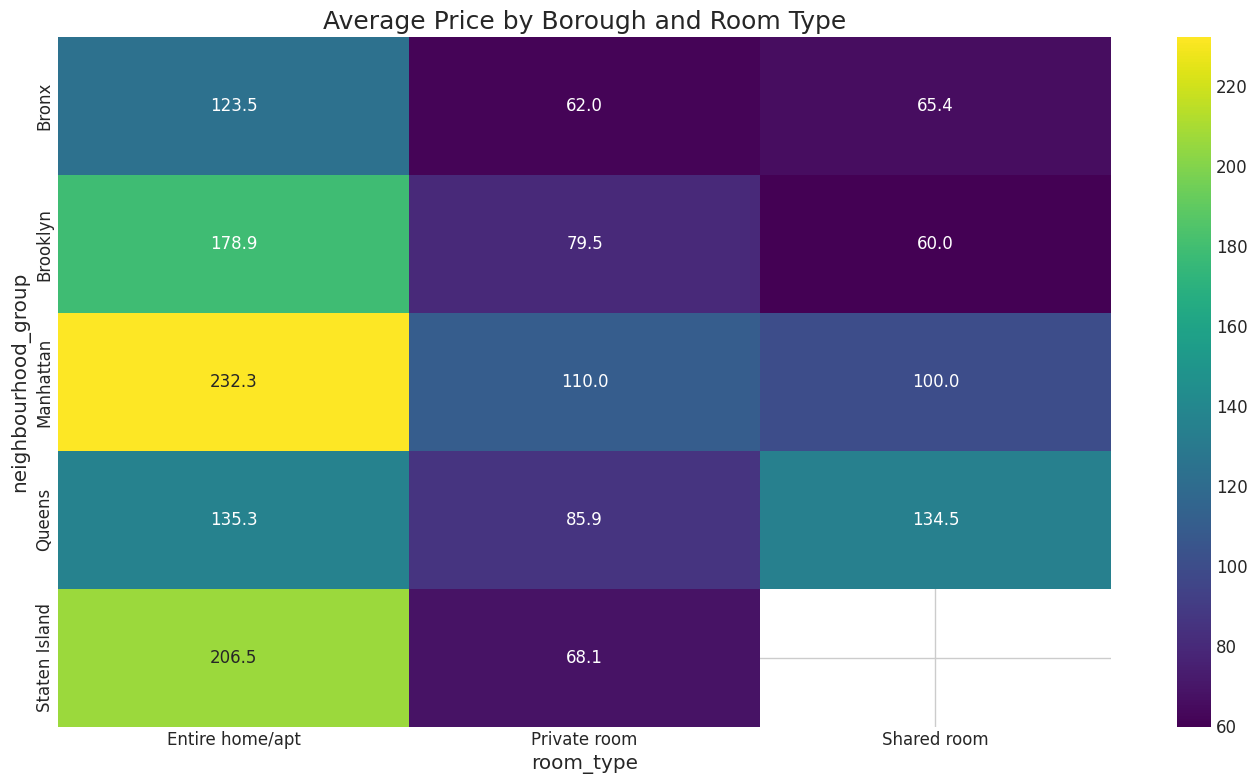

In [ ]:
# Price heatmap by borough and room type
plt.figure(figsize=(14, 8))
borough_room_price = df_viz.groupby(['neighbourhood_group', 'room_type'])['price'].mean().unstack()
sns.heatmap(borough_room_price, annot=True, fmt='.1f', cmap='viridis')
plt.title('Average Price by Borough and Room Type', fontsize=18)
plt.tight_layout()
plt.savefig('price_heatmap.png', dpi=300, bbox_inches='tight')



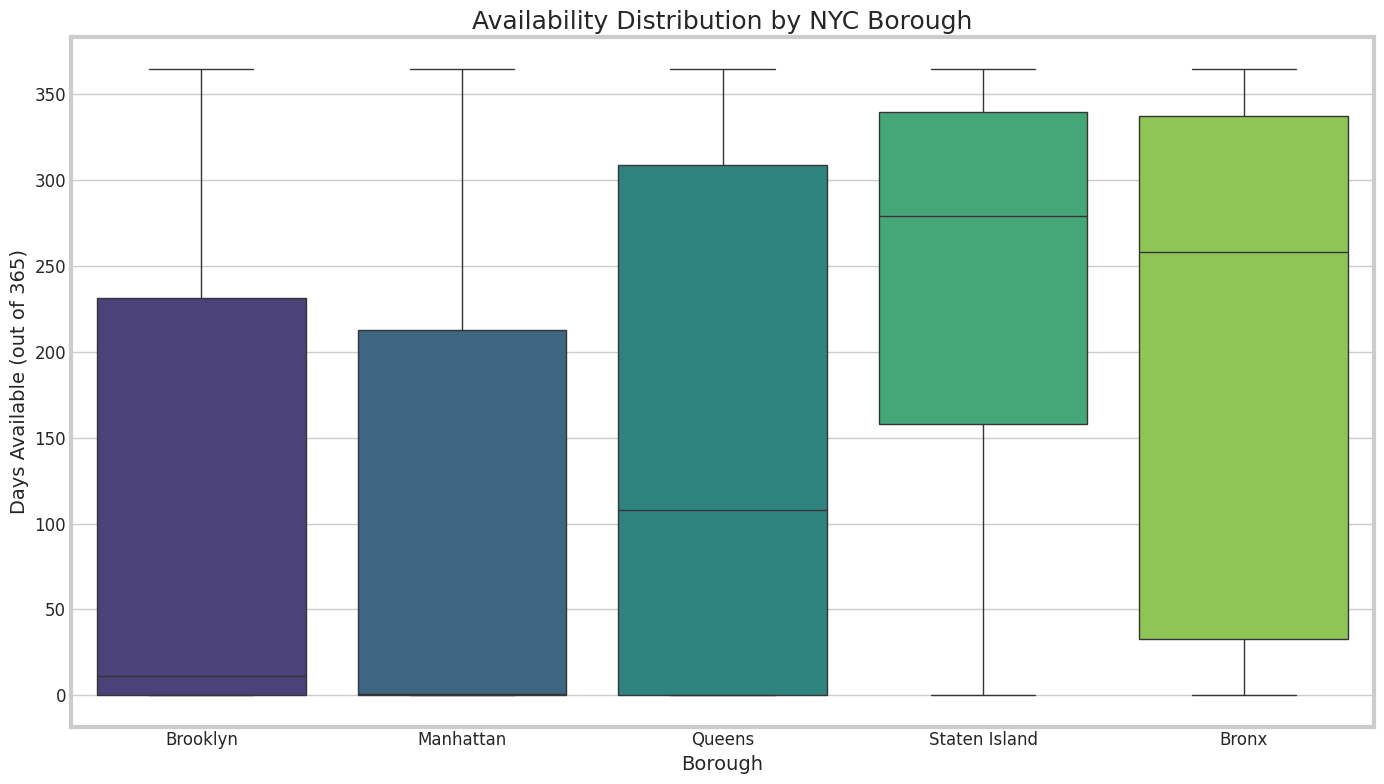

In [ ]:
# 3. AVAILABILITY ANALYSIS
# Availability by borough
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='neighbourhood_group', y='availability_365', data=df, palette='viridis')
ax.set_title('Availability Distribution by NYC Borough', fontsize=18)
ax.set_xlabel('Borough', fontsize=14)
ax.set_ylabel('Days Available (out of 365)', fontsize=14)
plt.tight_layout()
plt.savefig('availability_by_borough.png', dpi=300, bbox_inches='tight')



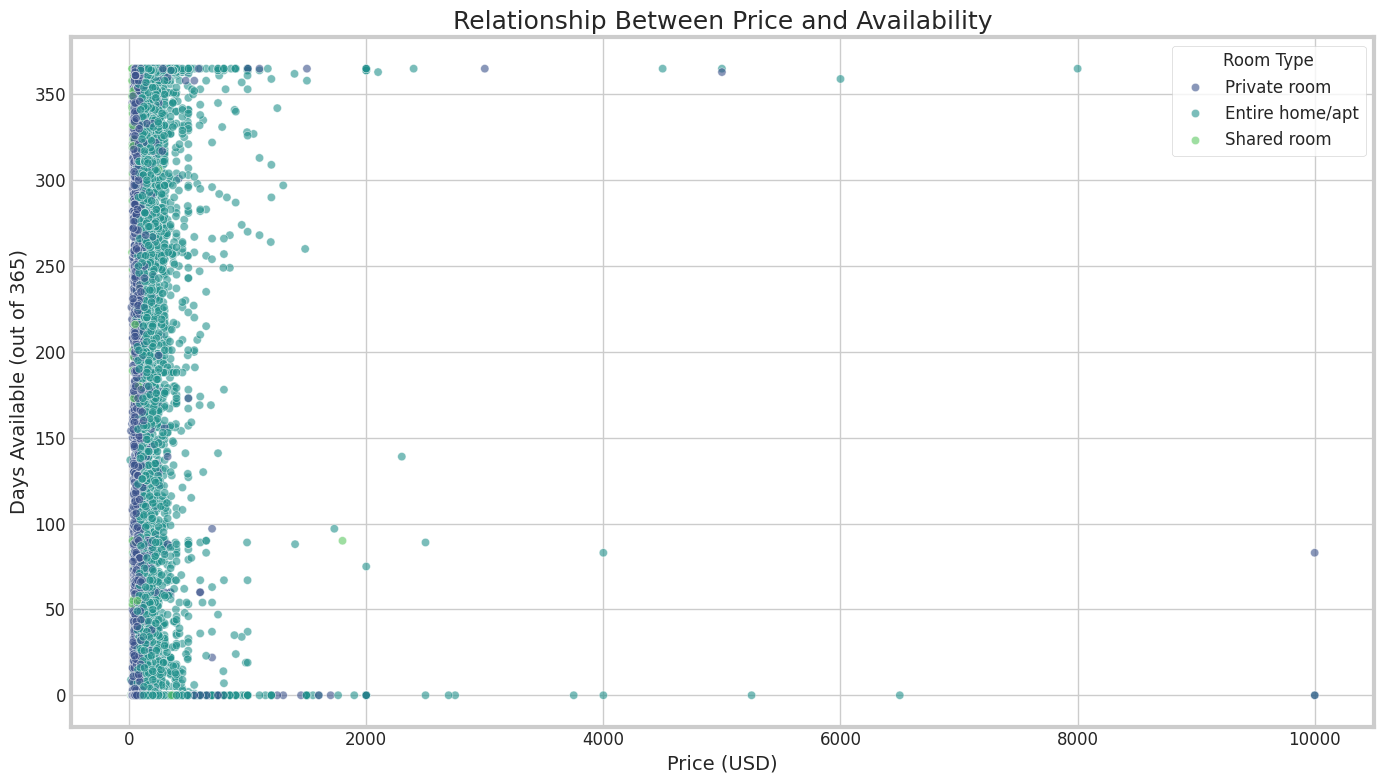

In [ ]:
# Relationship between price and availability
plt.figure(figsize=(14, 8))
sns.scatterplot(x='price', y='availability_365', data=df_viz, hue='room_type', alpha=0.6, palette='viridis')
plt.title('Relationship Between Price and Availability', fontsize=18)
plt.xlabel('Price (USD)', fontsize=14)
plt.ylabel('Days Available (out of 365)', fontsize=14)
plt.legend(title='Room Type')
plt.tight_layout()
plt.savefig('price_vs_availability.png', dpi=300, bbox_inches='tight')



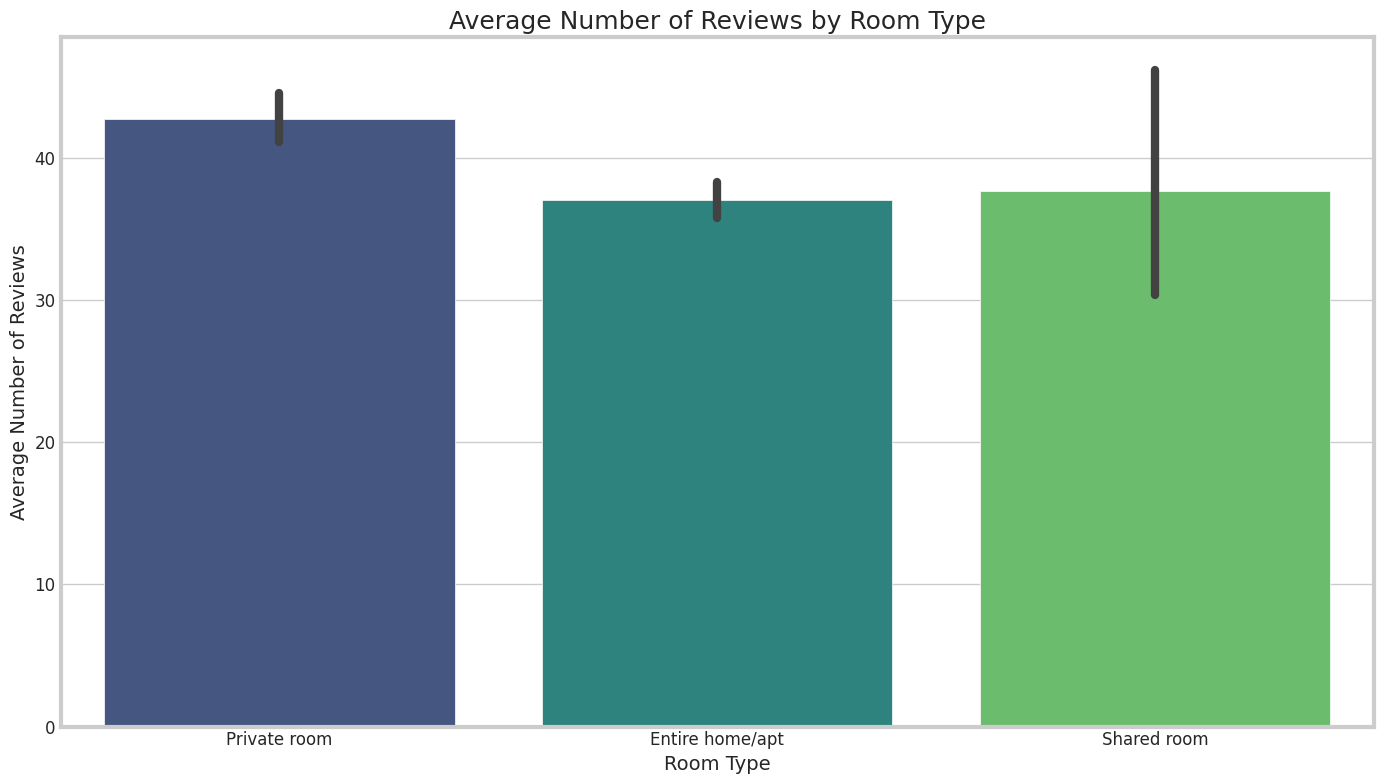

In [ ]:
# 4. REVIEW ANALYSIS
# Create a new feature for listings with reviews
df['has_reviews'] = df['number_of_reviews'] > 0
# Review count by room type
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='room_type', y='number_of_reviews', data=df, estimator=np.mean, palette='viridis')
ax.set_title('Average Number of Reviews by Room Type', fontsize=18)
ax.set_xlabel('Room Type', fontsize=14)
ax.set_ylabel('Average Number of Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('reviews_by_room_type.png', dpi=300, bbox_inches='tight')



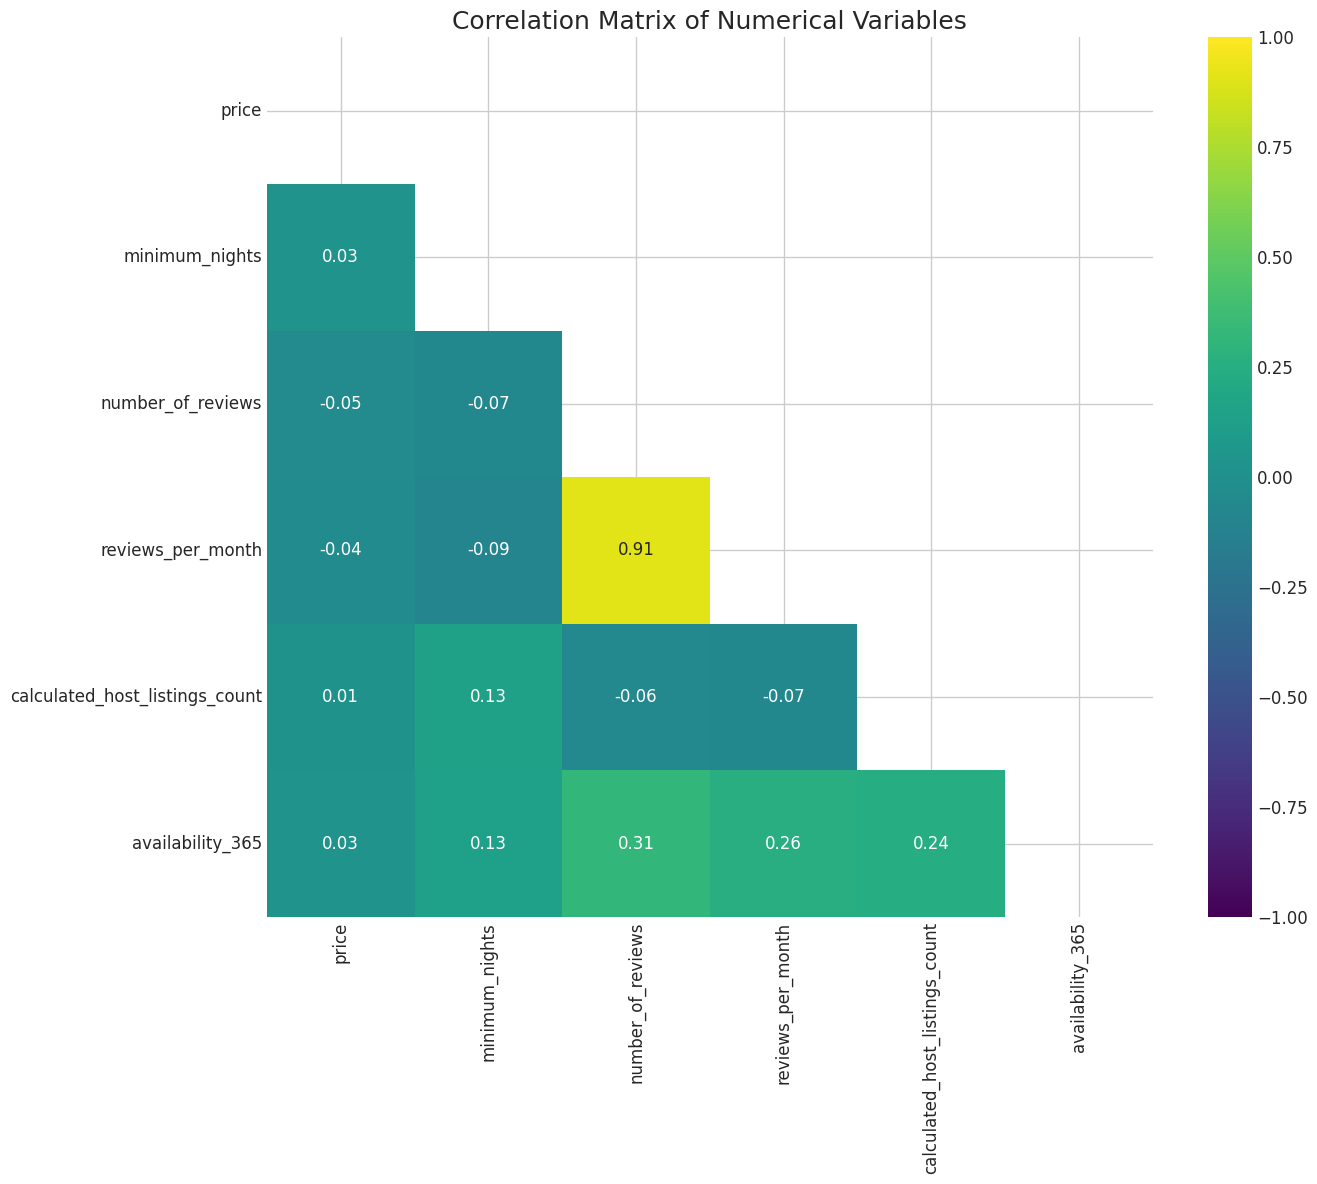

In [ ]:
# 6. CORRELATION ANALYSIS
# Select numerical columns for correlation
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                 'calculated_host_listings_count', 'availability_365']
correlation_df = df[numerical_cols].copy()

plt.figure(figsize=(14, 12))
correlation_matrix = correlation_df.corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis', mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Variables', fontsize=18)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')



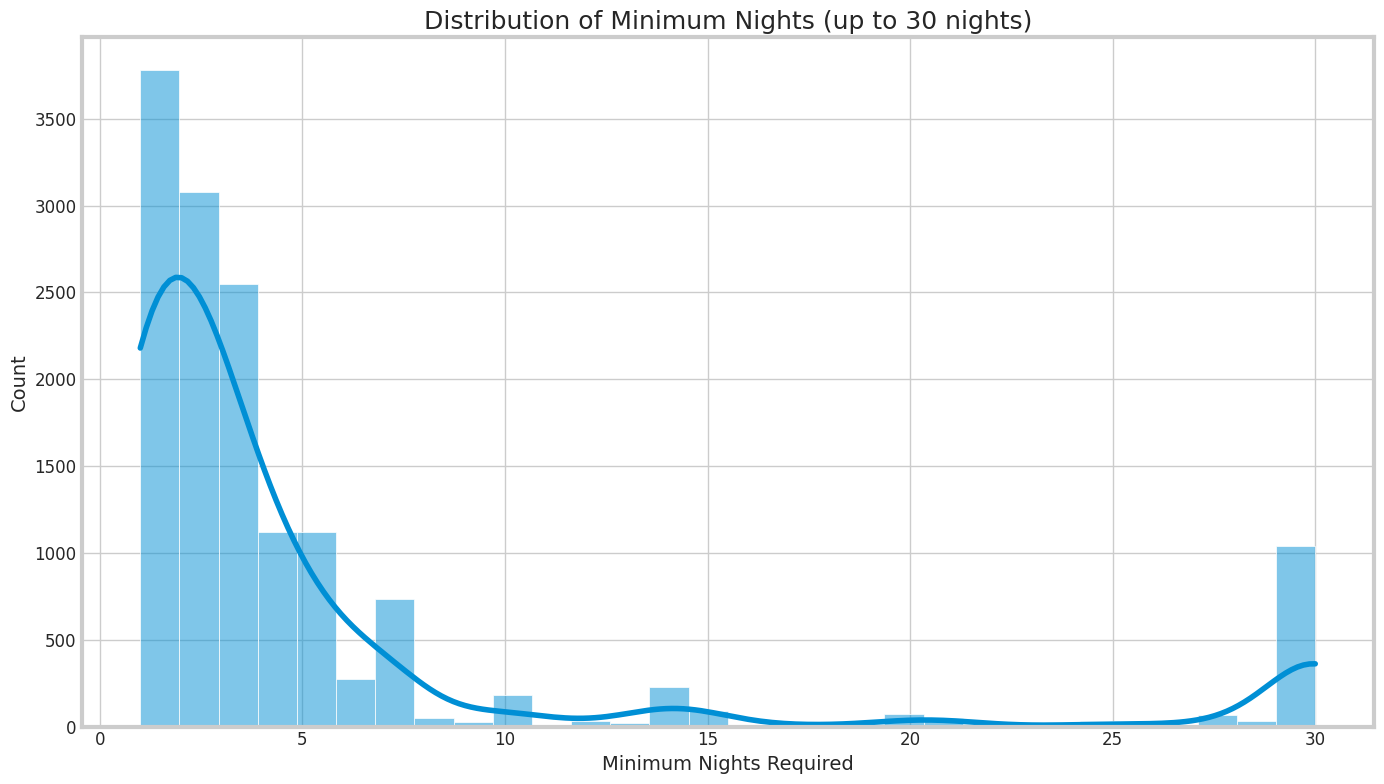

In [ ]:
# 7. MINIMUM NIGHTS ANALYSIS
# Distribution of minimum nights
plt.figure(figsize=(14, 8))
df_min_nights = df[df['minimum_nights'] <= 30].copy()  # Filter extreme values
sns.histplot(data=df_min_nights, x='minimum_nights', bins=30, kde=True)
plt.title('Distribution of Minimum Nights (up to 30 nights)', fontsize=18)
plt.xlabel('Minimum Nights Required', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.savefig('minimum_nights_dist.png', dpi=300, bbox_inches='tight')



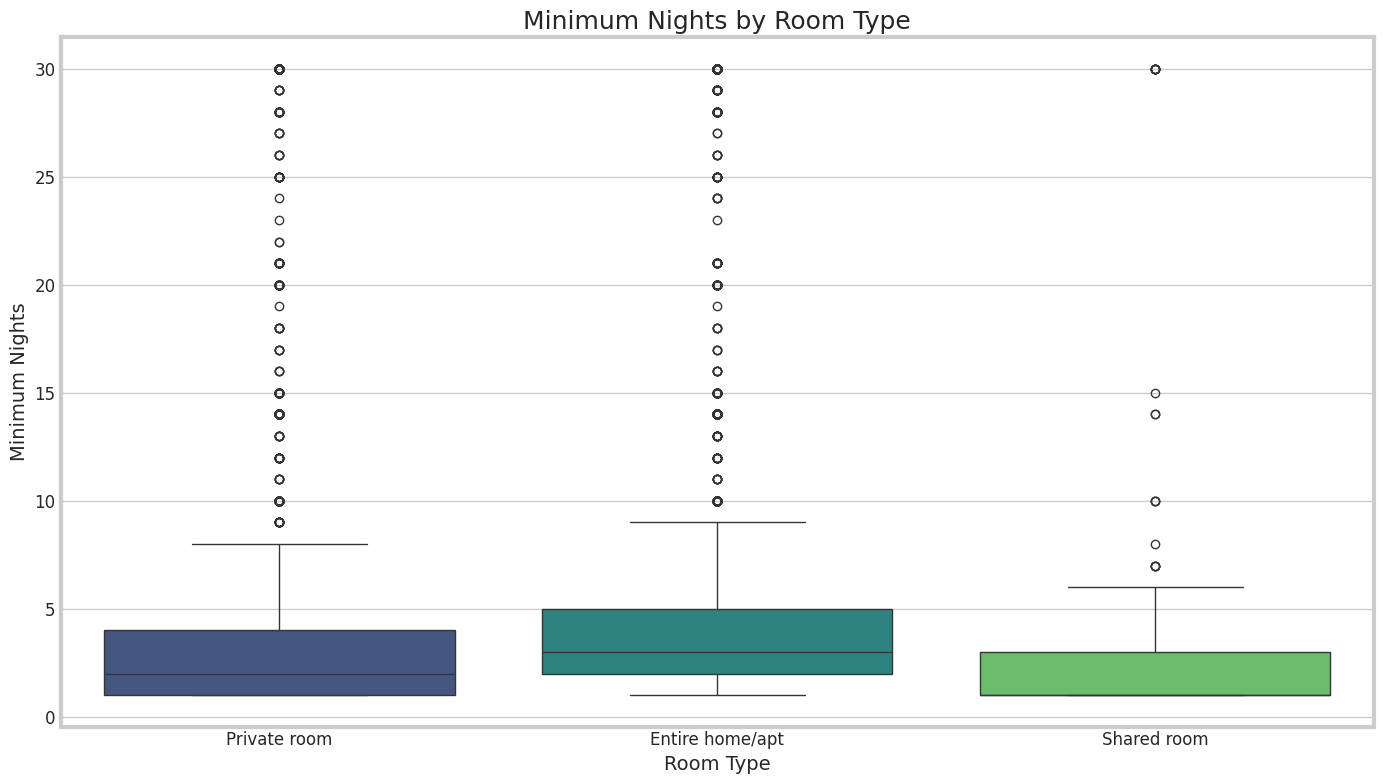

In [ ]:
# Minimum nights by room type
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='room_type', y='minimum_nights', data=df_min_nights, palette='viridis')
ax.set_title('Minimum Nights by Room Type', fontsize=18)
ax.set_xlabel('Room Type', fontsize=14)
ax.set_ylabel('Minimum Nights', fontsize=14)
plt.tight_layout()
plt.savefig('minimum_nights_by_room_type.png', dpi=300, bbox_inches='tight')




<Figure size 1400x800 with 0 Axes>

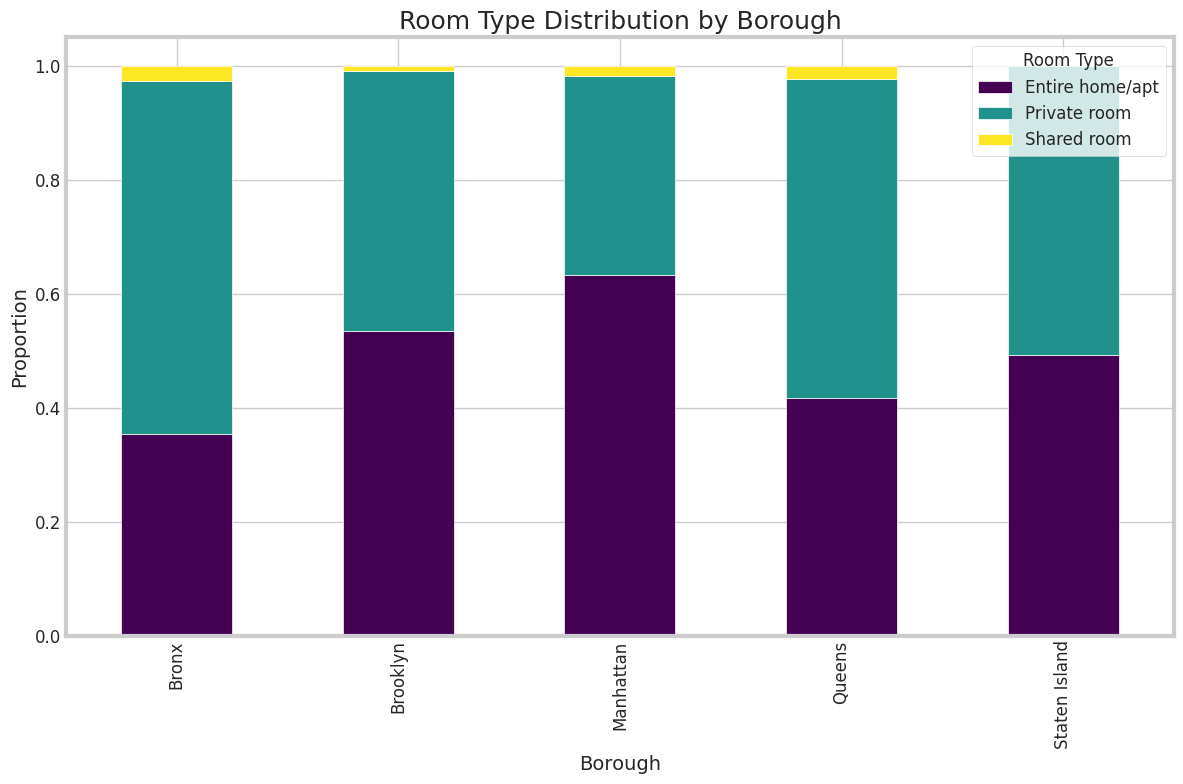

In [ ]:
# 9. ROOM TYPE DISTRIBUTION
# Distribution of room types across NYC
plt.figure(figsize=(14, 8))
room_type_counts = df.groupby(['neighbourhood_group', 'room_type']).size().unstack()
room_type_proportions = room_type_counts.div(room_type_counts.sum(axis=1), axis=0)
room_type_proportions.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Room Type Distribution by Borough', fontsize=18)
plt.xlabel('Borough', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.legend(title='Room Type')
plt.tight_layout()
plt.savefig('room_type_distribution.png', dpi=300, bbox_inches='tight')



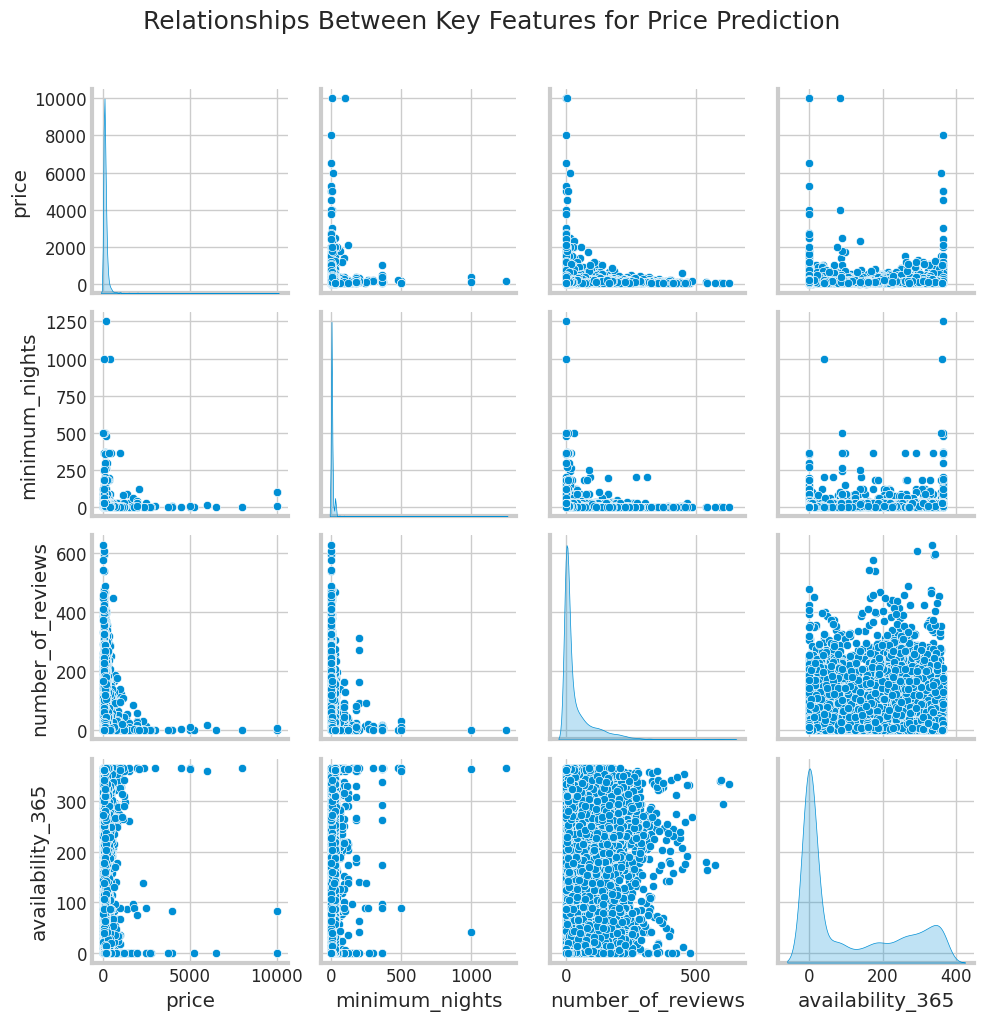

In [ ]:
# 10. PRICE PREDICTION INSIGHTS
# Feature relationships for potential price modeling
# Let's create a pairplot of key features
features_for_price = df_viz[['price', 'minimum_nights', 'number_of_reviews', 'availability_365']]
g = sns.pairplot(features_for_price, diag_kind='kde')
g.fig.suptitle('Relationships Between Key Features for Price Prediction', y=1.02, fontsize=18)
plt.tight_layout()
plt.savefig('price_feature_relationships.png', dpi=300, bbox_inches='tight')



In [ ]:
# Generate summary statistics by neighborhood group and room type
summary_stats = df_viz.groupby(['neighbourhood_group', 'room_type']).agg({
    'price': ['mean', 'median', 'std', 'min', 'max', 'count'],
    'minimum_nights': ['mean', 'median'],
    'number_of_reviews': ['mean', 'sum'],
    'availability_365': ['mean']
}).round(2)

# Save statistics to CSV for detailed analysis
summary_stats.to_csv('nyc_airbnb_summary_stats.csv')
print(summary_stats,"\n")
print("Data exploration and visualization completed successfully!")

                                      price                                \
                                       mean median     std   min      max   
neighbourhood_group room_type                                               
Bronx               Entire home/apt  123.51  105.0   66.12  37.0    450.0   
                    Private room      61.96   50.5   61.27  25.0    680.0   
                    Shared room       65.40   45.0   47.99  32.0    150.0   
Brooklyn            Entire home/apt  178.92  147.0  233.96  35.0   8000.0   
                    Private room      79.54   65.0  121.27  18.0   5000.0   
                    Shared room       59.95   45.0   42.70  25.0    200.0   
Manhattan           Entire home/apt  232.25  179.0  294.59  10.0   9999.0   
                    Private room     109.97   90.0  226.41  16.0   9999.0   
                    Shared room      100.05   75.0  118.61  29.0   1000.0   
Queens              Entire home/apt  135.33  118.5   72.32  40.0    600.0   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14883 entries, 0 to 14882
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             14883 non-null  object 
 1   latitude                        14883 non-null  float64
 2   longitude                       14883 non-null  float64
 3   room_type                       14883 non-null  object 
 4   price                           14883 non-null  float64
 5   minimum_nights                  14883 non-null  float64
 6   number_of_reviews               14883 non-null  float64
 7   reviews_per_month               12428 non-null  float64
 8   calculated_host_listings_count  14883 non-null  float64
 9   availability_365                14883 non-null  float64
 10  NEW_total_cost                  14883 non-null  float64
 11  NEW_estimated_listed_months     12428 non-null  float64
 12  NEW_availability_ratio          14883

In [ ]:


class DataAnalyzer:
    @staticmethod
    def identify_column_types(data):
        """Identify numerical and categorical columns in a DataFrame."""
        num_cols = data.select_dtypes(include=[np.number]).columns
        cat_cols = data.select_dtypes(exclude=[np.number]).columns
        return num_cols, cat_cols




class MultiColumnImputer(BaseEstimator, TransformerMixin):
    """Impute missing values in numerical and categorical columns."""
    def __init__(self, num_strategy='knn', cat_strategy='constant', cat_fill_value='missing'):
        self.num_strategy = num_strategy
        self.cat_strategy = cat_strategy
        self.cat_fill_value = cat_fill_value

    def fit(self, X, y=None):
        self.num_cols, self.cat_cols = DataAnalyzer.identify_column_types(X)

        # Fit numerical imputer
        if self.num_strategy == 'knn':
            self.num_imputer = KNNImputer()
        else:
            self.num_imputer = SimpleImputer(strategy=self.num_strategy)

        if len(self.num_cols) > 0:
            self.num_imputer.fit(X[self.num_cols])

        # Fit categorical imputer
        self.cat_imputer = SimpleImputer(strategy=self.cat_strategy, fill_value=self.cat_fill_value)
        if len(self.cat_cols) > 0:
            self.cat_imputer.fit(X[self.cat_cols])

        return self

    def transform(self, X):
        X_copy = X.copy()

        # Transform numerical columns
        if len(self.num_cols) > 0:
            X_copy[self.num_cols] = self.num_imputer.transform(X_copy[self.num_cols])

        # Transform categorical columns
        if len(self.cat_cols) > 0:
            X_copy[self.cat_cols] = self.cat_imputer.transform(X_copy[self.cat_cols])

        return X_copy


class OutlierHandler(BaseEstimator, TransformerMixin):
    """Handle outliers using IQR-based clamping."""
    def __init__(self, multiplier=5):
        self.multiplier = multiplier
        self.bounds = {}

    def fit(self, X, y=None):
        num_cols, _ = DataAnalyzer.identify_column_types(X)
        self.bounds = {}

        for col in num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - (self.multiplier * IQR)
            upper_bound = Q3 + (self.multiplier * IQR)

            self.bounds[col] = {'lower': lower_bound, 'upper': upper_bound}

        return self

    def transform(self, X):
        X_copy = X.copy()

        for col, bounds in self.bounds.items():
            if col in X_copy.columns:
                X_copy[col] = np.clip(X_copy[col], bounds['lower'], bounds['upper'])

        return X_copy



class SkewnessHandler(BaseEstimator, TransformerMixin):
    """Apply log transformation to skewed numerical features."""
    def __init__(self, threshold=0.75):
        self.threshold = threshold
        self.skewed_features = []

    def fit(self, X, y=None):
        num_cols, _ = DataAnalyzer.identify_column_types(X)
        self.skewed_features = []

        for col in num_cols:
            # Calculate skewness
            skewness = X[col].skew()
            if abs(skewness) > self.threshold:
                self.skewed_features.append(col)

        return self

    def transform(self, X):
        X_copy = X.copy()

        for col in self.skewed_features:
            if col in X_copy.columns:
                # Add small constant to handle zeros
                X_copy[col] = np.log1p(np.abs(X_copy[col]))

        return X_copy



class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Encode categorical variables using different strategies."""
    def __init__(self, ordinal_cols=None, nominal_cols=None):
        self.ordinal_cols = ordinal_cols if ordinal_cols else []
        self.nominal_cols = nominal_cols if nominal_cols else []
        self.ordinal_encoders = {}
        self.ohe = None
        self.ohe_feature_names = None

    def fit(self, X, y=None):
        # Fit Label Encoders for ordinal categories
        for col in self.ordinal_cols:
            if col in X.columns:
                le = LabelEncoder()
                le.fit(X[col].astype(str))
                self.ordinal_encoders[col] = le

        # Fit OneHotEncoder for nominal categories
        cols_to_encode = [col for col in self.nominal_cols if col in X.columns]
        if cols_to_encode:
            self.ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
            self.ohe.fit(X[cols_to_encode])
            self.ohe_feature_names = self.ohe.get_feature_names_out(cols_to_encode)

        return self

    def transform(self, X):
        X_copy = X.copy()

        # Transform ordinal categories
        for col, encoder in self.ordinal_encoders.items():
            if col in X_copy.columns:
                # Handle unknown categories
                X_copy[col] = X_copy[col].astype(str)
                unknown_mask = ~X_copy[col].isin(encoder.classes_)
                if unknown_mask.any():
                    X_copy.loc[unknown_mask, col] = encoder.classes_[0]
                X_copy[col] = encoder.transform(X_copy[col])

        # Transform nominal categories
        cols_to_encode = [col for col in self.nominal_cols if col in X_copy.columns]
        if cols_to_encode and self.ohe:
            ohe_result = self.ohe.transform(X_copy[cols_to_encode])
            ohe_df = pd.DataFrame(ohe_result, index=X_copy.index, columns=self.ohe_feature_names)

            # Drop original columns and join one-hot encoded
            X_copy = X_copy.drop(columns=cols_to_encode)
            X_copy = pd.concat([X_copy, ohe_df], axis=1)

        return X_copy



class NumericalScaler(BaseEstimator, TransformerMixin):
    """Scale numerical features using various techniques."""
    def __init__(self, scaling_method='standard'):
        """
        Initialize the numerical scaler.

        Parameters:
        -----------
        scaling_method : str, default='standard'
            The scaling method to use. Options:
            - 'standard': StandardScaler (zero mean, unit variance)
            - 'minmax': MinMaxScaler (scale to a range, default 0-1)
            - 'robust': RobustScaler (scale using quantiles, robust to outliers)
            - 'maxabs': MaxAbsScaler (scale by maximum absolute value)
            - 'normalizer': Normalizer (scale samples to unit norm)
            - None: No scaling
        """
        self.scaling_method = scaling_method
        self.scaler = None

    def fit(self, X, y=None):
        # Only apply to numerical columns
        self.num_cols, _ = DataAnalyzer.identify_column_types(X)

        if not self.scaling_method or len(self.num_cols) == 0:
            return self

        # Select the appropriate scaler
        if self.scaling_method == 'standard':
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler()
        elif self.scaling_method == 'minmax':
            from sklearn.preprocessing import MinMaxScaler
            self.scaler = MinMaxScaler()
        elif self.scaling_method == 'robust':
            from sklearn.preprocessing import RobustScaler
            self.scaler = RobustScaler()
        elif self.scaling_method == 'maxabs':
            from sklearn.preprocessing import MaxAbsScaler
            self.scaler = MaxAbsScaler()
        elif self.scaling_method == 'normalizer':
            from sklearn.preprocessing import Normalizer
            self.scaler = Normalizer()
        else:
            raise ValueError(f"Unknown scaling method: {self.scaling_method}")

        # Fit the scaler
        if self.scaler and len(self.num_cols) > 0:
            self.scaler.fit(X[self.num_cols])

        return self

    def transform(self, X):
        X_copy = X.copy()

        if self.scaler and len(self.num_cols) > 0:
            X_copy[self.num_cols] = self.scaler.transform(X_copy[self.num_cols])

        return X_copy



def create_pipeline(feature_engineering_fn=None, ordinal_cols=None, nominal_cols=None, target_col=None):
    """
    Create a complete machine learning preprocessing pipeline.

    Parameters:
    -----------
    ordinal_cols : list, optional
        List of ordinal categorical column names.
    nominal_cols : list, optional
        List of nominal categorical column names.
    target_col : str, optional
        Target column name for correlation analysis.

    Returns:
    --------
    sklearn.pipeline.Pipeline
        A complete preprocessing pipeline.
    """
    steps = []


    steps.extend([
    ('impute_missing', MultiColumnImputer()),
    ('handle_outliers', OutlierHandler(multiplier=5)),
    ('handle_skewness', SkewnessHandler(threshold=0.9)),
    ('encode_categorical', CategoricalEncoder(ordinal_cols=ordinal_cols, nominal_cols=nominal_cols)),
    ('scale_numerical', NumericalScaler(scaling_method='standard'))
])

    return Pipeline(steps)

# Example usage:
if __name__ == "__main__":
    # Define your feature engineering function
    def engineer_features(df):
        df_out = df.copy()
        # Add your feature engineering logic here
        return df_out

    # Define categorical columns
    ordinal_cols = []
    nominal_cols = ['neighbourhood_group','room_type']

    # Create the pipeline
    pipeline = create_pipeline(
        feature_engineering_fn=engineer_features,
        ordinal_cols=ordinal_cols,
        nominal_cols=nominal_cols,
        target_col='price'
    )
    # Apply the pipeline to your dataset
    X = df.drop(['price'], axis=1)
    y = np.log1p(df['price'])

    # Now you can use the pipeline:
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    pipeline.fit(X_train)
    X_train_transformed = pipeline.transform(X_train)
    X_test_transformed = pipeline.transform(X_test)

In [ ]:
X_train_transformed.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,NEW_total_cost,NEW_estimated_listed_months,NEW_availability_ratio,NEW_daily_average_reviews,NEW_annual_income,NEW_average_stay_duration,NEW_house_occupancy_rate,NEW_minimum_income,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
9668,-1.696703,-0.114433,-0.132951,-0.473565,-0.713468,0.536900,-0.797807,-0.952658,-0.436050,-0.797807,-0.610720,-1.047186,-0.436050,0.797807,-0.952658,-0.111061,1.132321,-0.941334,-0.284720,-0.069723,-1.152109,1.189526,-0.125839
7847,0.603921,-1.065572,-0.503552,-1.405182,-0.652671,-0.519413,-0.797807,-0.952658,-0.861162,-0.797807,-0.580033,-1.047186,-0.861162,0.797807,-0.952658,-0.111061,-0.883142,-0.941334,3.512225,-0.069723,-1.152109,1.189526,-0.125839
7237,-0.960727,0.322773,-0.503552,-0.072339,-0.425681,-0.519413,-0.797807,0.026373,-0.921612,-0.797807,-0.457612,-1.047186,-0.921612,0.797807,0.026373,-0.111061,1.132321,-0.941334,-0.284720,-0.069723,0.867973,-0.840671,-0.125839
1338,0.013444,1.245868,0.759985,0.652818,-0.172605,-0.519413,0.818563,1.137819,1.776715,0.818563,-0.305313,1.121207,1.776715,-0.818563,1.137819,-0.111061,-0.883142,1.062322,-0.284720,-0.069723,0.867973,-0.840671,-0.125839
10013,-0.600544,0.481734,0.154510,1.260504,1.475922,-0.519413,-0.797807,0.722270,-0.267920,-0.797807,1.247125,-1.047186,-0.267920,0.797807,0.722270,-0.111061,1.132321,-0.941334,-0.284720,-0.069723,0.867973,-0.840671,-0.125839


In [ ]:
print(X_train_transformed.shape)
print(X_test_transformed.shape )

(11162, 23)
(3721, 23)


RMSE: 0.1754 (LR)
R^2 Score: 0.9084 (LR)
MAE: 0.1012 (LR)
MSE: 0.0367 (LR)
Execution Time: 0.22 seconds

RMSE: 0.1754 (Ridge)
R^2 Score: 0.9084 (Ridge)
MAE: 0.1012 (Ridge)
MSE: 0.0367 (Ridge)
Execution Time: 0.14 seconds

RMSE: 0.6501 (Lasso)
R^2 Score: -0.0004 (Lasso)
MAE: 0.494 (Lasso)
MSE: 0.4009 (Lasso)
Execution Time: 0.13 seconds

RMSE: 0.6501 (ElasticNet)
R^2 Score: -0.0004 (ElasticNet)
MAE: 0.494 (ElasticNet)
MSE: 0.4009 (ElasticNet)
Execution Time: 0.17 seconds

RMSE: 0.3456 (KNN)
R^2 Score: 0.712 (KNN)
MAE: 0.2297 (KNN)
MSE: 0.1154 (KNN)
Execution Time: 1.15 seconds

RMSE: 0.1472 (CART)
R^2 Score: 0.9382 (CART)
MAE: 0.0331 (CART)
MSE: 0.0248 (CART)
Execution Time: 1.34 seconds

RMSE: 0.1066 (RF)
R^2 Score: 0.9506 (RF)
MAE: 0.0272 (RF)
MSE: 0.0198 (RF)
Execution Time: 67.17 seconds

RMSE: 0.1436 (GBM)
R^2 Score: 0.9325 (GBM)
MAE: 0.0873 (GBM)
MSE: 0.027 (GBM)
Execution Time: 27.69 seconds

RMSE: 0.1068 (XGBoost)
R^2 Score: 0.9545 (XGBoost)
MAE: 0.0429 (XGBoost)
MSE: 0.0182 (XG

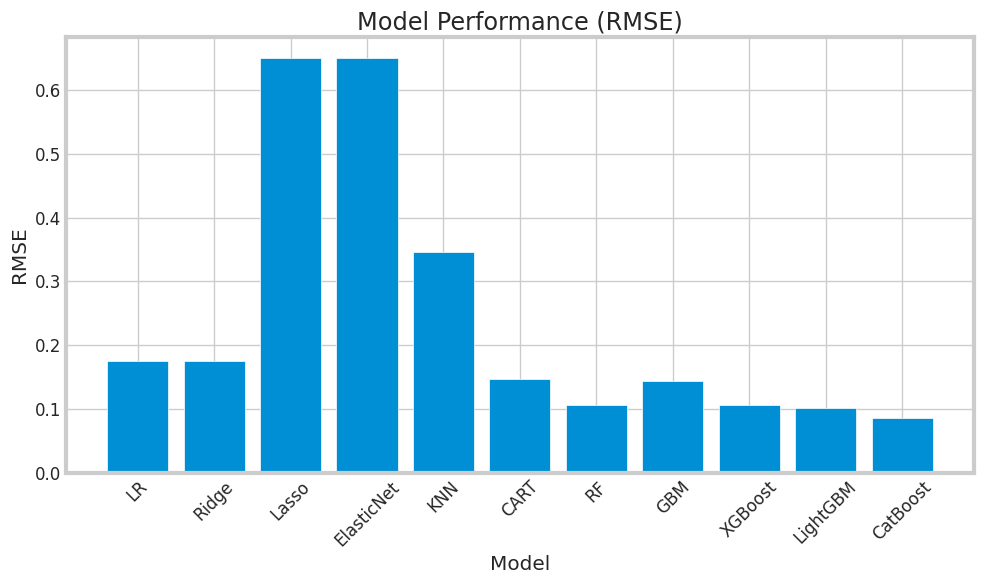

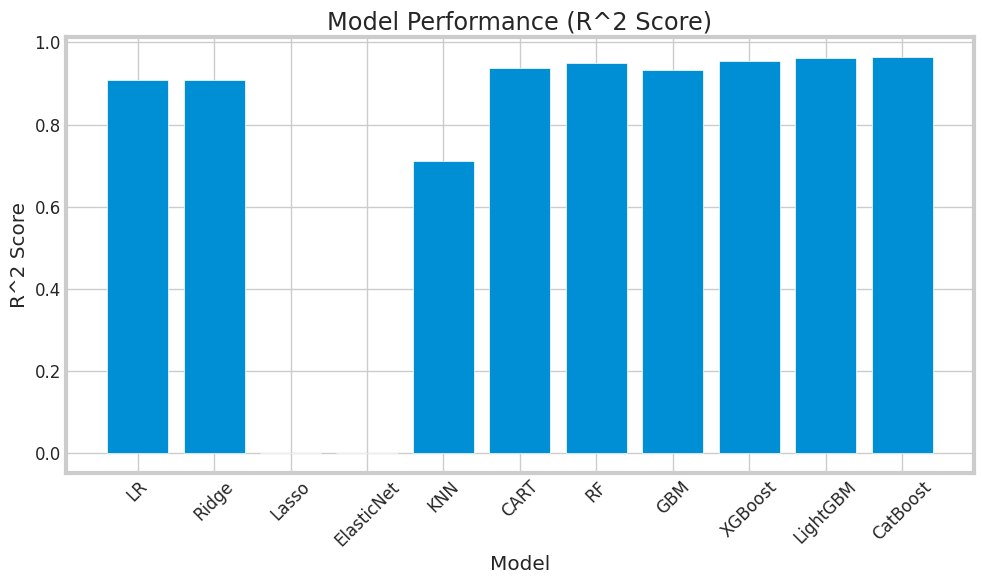

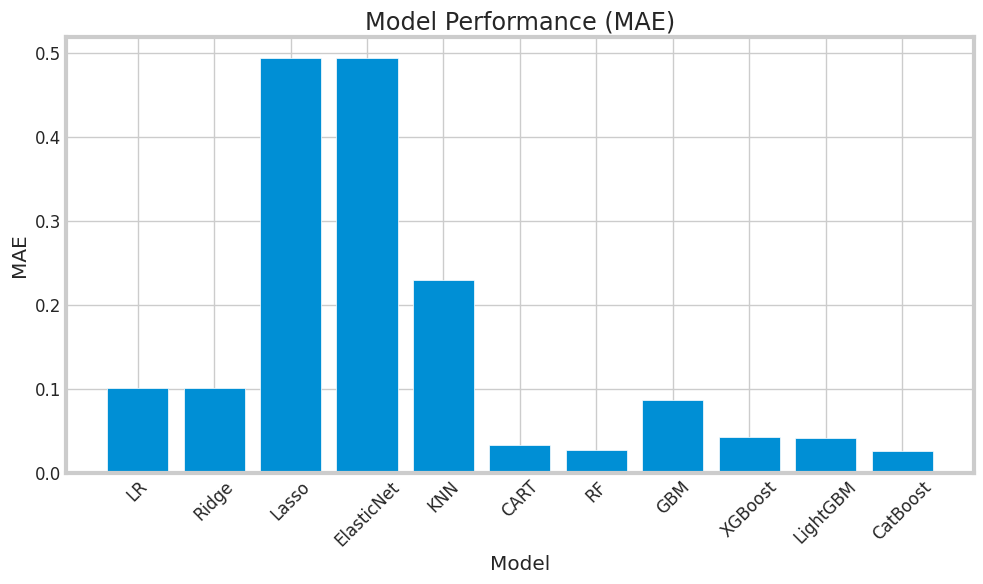

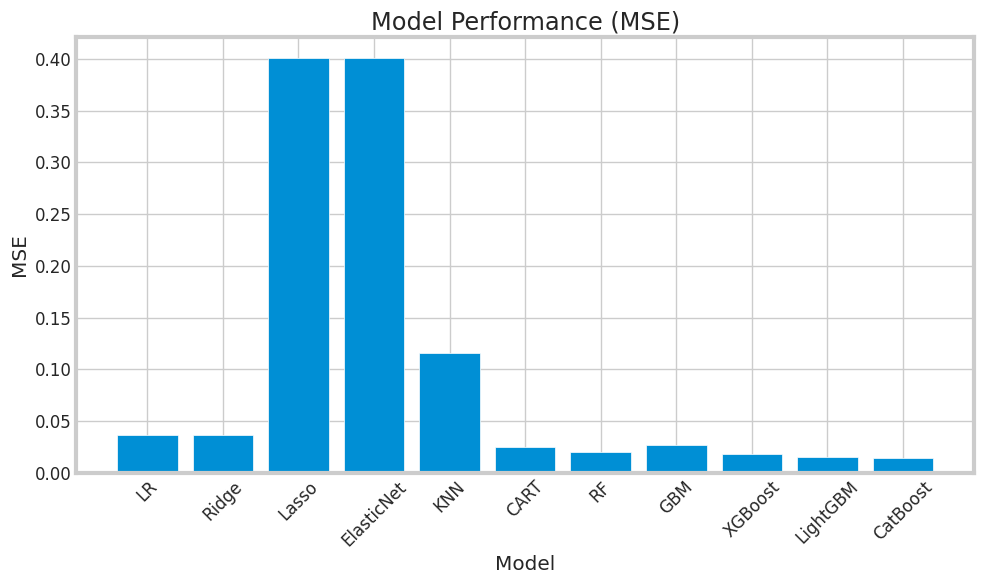

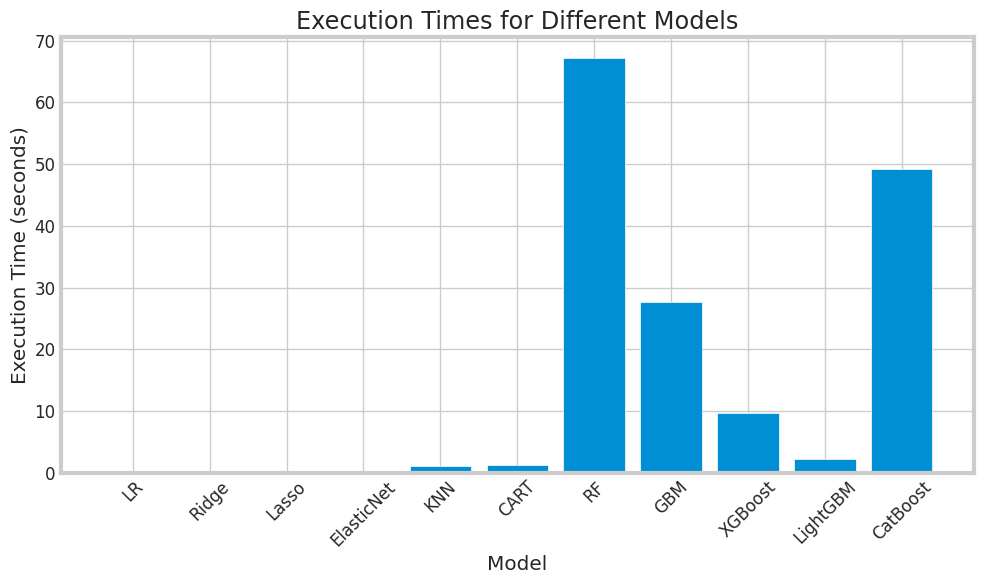

In [ ]:
models = [('LR', LinearRegression()),
          ("Ridge", Ridge()),
          ("Lasso", Lasso()),
          ("ElasticNet", ElasticNet()),
          ('KNN', KNeighborsRegressor()),
          ('CART', DecisionTreeRegressor()),
          ('RF', RandomForestRegressor()),
          #('SVR', SVR()),
          ('GBM', GradientBoostingRegressor()),
          ("XGBoost", XGBRegressor(objective='reg:squarederror')),
          ("LightGBM", LGBMRegressor()),
          ("CatBoost", CatBoostRegressor(verbose=False))]

rmse_scores = []
r2_scores = []
mae_scores = []
mse_scores = []
execution_times = []

for name, regressor in models:
    start_time = time.time()

    # Fit the model
    regressor.fit(X_train_transformed, y_train)

    # Make predictions
    y_pred = regressor.predict(X_test_transformed)

    # Calculate RMSE using cross validation on transformed data
    rmse = np.mean(np.sqrt(-cross_val_score(regressor,
                                          X_train_transformed,
                                          y_train,
                                          cv=5,
                                          scoring="neg_mean_squared_error")))
    rmse_scores.append(rmse)

    # Calculate R^2 score
    r2 = metrics.r2_score(y_test, y_pred)
    r2_scores.append(r2)

    # Calculate MAE
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)

    # Calculate MSE
    mse = metrics.mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)

    # Calculate the execution time of the model
    execution_time = time.time() - start_time
    execution_times.append(execution_time)

    print(f"RMSE: {round(rmse, 4)} ({name})")
    print(f"R^2 Score: {round(r2, 4)} ({name})")
    print(f"MAE: {round(mae, 4)} ({name})")
    print(f"MSE: {round(mse, 4)} ({name})")
    print(f"Execution Time: {round(execution_time, 2)} seconds\n")

# Plot RMSE scores
plt.figure(figsize=(10, 6))
plt.bar([name for name, _ in models], rmse_scores)
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Performance (RMSE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot R^2 scores
plt.figure(figsize=(10, 6))
plt.bar([name for name, _ in models], r2_scores)
plt.xlabel("Model")
plt.ylabel("R^2 Score")
plt.title("Model Performance (R^2 Score)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot MAE scores
plt.figure(figsize=(10, 6))
plt.bar([name for name, _ in models], mae_scores)
plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Performance (MAE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot MSE scores
plt.figure(figsize=(10, 6))
plt.bar([name for name, _ in models], mse_scores)
plt.xlabel("Model")
plt.ylabel("MSE")
plt.title("Model Performance (MSE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot execution times
plt.figure(figsize=(10, 6))
plt.bar([name for name, _ in models], execution_times)
plt.xlabel("Model")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Times for Different Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()